In [1]:
!pip install -q opendatasets torch torchvision scikit-learn seaborn matplotlib grad-cam lime tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 49.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 28.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import os
import copy
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset, ConcatDataset, random_split
from torchvision import datasets, transforms

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    cohen_kappa_score, roc_auc_score,
    confusion_matrix, classification_report
)

# ---- Reproducibility ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

CLASS_NAMES = ['Mild Impairment', 'Moderate Impairment', 'No Impairment', 'Very Mild Impairment']
NUM_CLASSES = len(CLASS_NAMES)
IMG_SIZE = 128

Using device: cuda


In [3]:
import opendatasets as od

primary_dataset_url = "https://www.kaggle.com/datasets/lukechugh/best-alzheimer-mri-dataset-99-accuracy/data"
od.download(primary_dataset_url)

data_dir = "/content/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset"
assert os.path.exists(data_dir), f"Dataset folder not found at {data_dir}. Check the download output above for the actual path."
print("Dataset ready at:", data_dir)
print("Train classes:", os.listdir(os.path.join(data_dir, "train")))
print("Test classes:", os.listdir(os.path.join(data_dir, "test")))

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: muhammadshahan
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/lukechugh/best-alzheimer-mri-dataset-99-accuracy


100%|██████████| 71.5M/71.5M [00:02<00:00, 27.1MB/s]



Dataset ready at: /content/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset
Train classes: ['No Impairment', 'Mild Impairment', 'Moderate Impairment', 'Very Mild Impairment']
Test classes: ['No Impairment', 'Mild Impairment', 'Moderate Impairment', 'Very Mild Impairment']


In [4]:
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

eval_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

full_train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=train_transforms)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=eval_transforms)

# Sanity check: class-to-index mapping must match CLASS_NAMES order
print("ImageFolder class_to_idx:", full_train_dataset.class_to_idx)

# 80/20 train/val split (matches thesis Section 3.3/3.4)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(
    full_train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

BATCH_SIZE = 8
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

ImageFolder class_to_idx: {'Mild Impairment': 0, 'Moderate Impairment': 1, 'No Impairment': 2, 'Very Mild Impairment': 3}
Train samples: 8192
Validation samples: 2048
Test samples: 1279


Train class distribution: {'Mild Impairment': 2560, 'Moderate Impairment': 2560, 'No Impairment': 2560, 'Very Mild Impairment': 2560}
Test class distribution: {'Mild Impairment': 179, 'Moderate Impairment': 12, 'No Impairment': 640, 'Very Mild Impairment': 448}


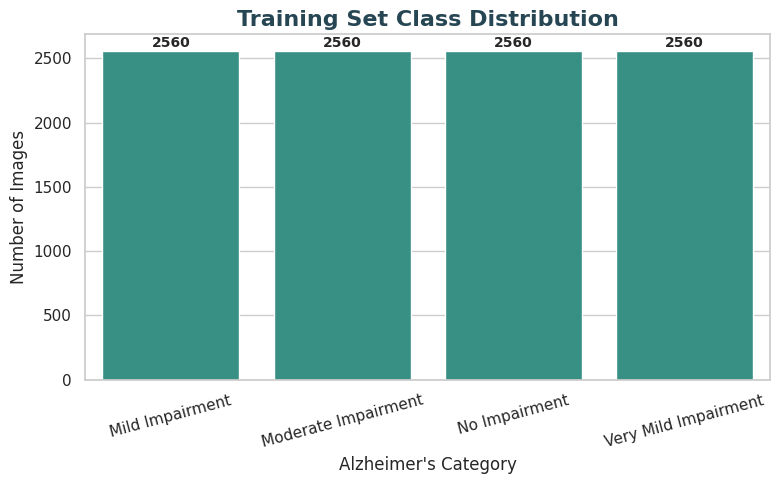

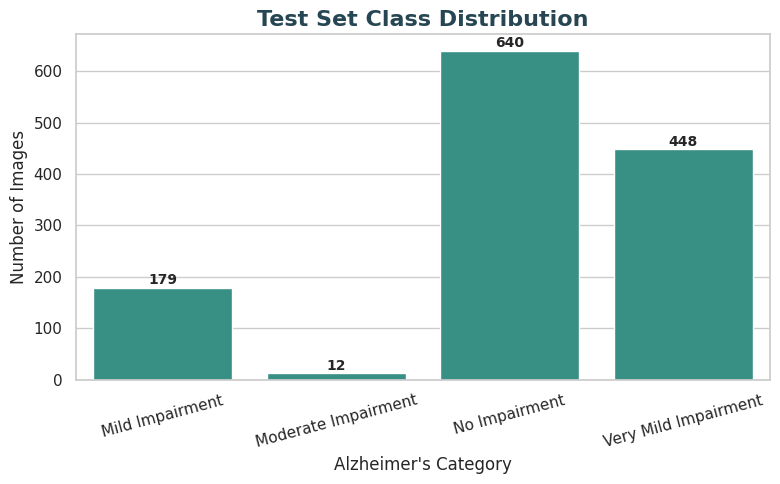

In [5]:
def count_images_in_folders(root_dir):
    counts = {}
    for class_folder in sorted(os.listdir(root_dir)):
        class_path = os.path.join(root_dir, class_folder)
        if os.path.isdir(class_path):
            counts[class_folder] = len(os.listdir(class_path))
    return counts

def plot_distribution(counts, title, bar_color="#2a9d8f"):
    plt.figure(figsize=(8, 5))
    sns.set(style="whitegrid")
    sns.barplot(x=list(counts.keys()), y=list(counts.values()), color=bar_color)
    plt.title(title, fontsize=16, fontweight='bold', color="#264653")
    plt.xlabel("Alzheimer's Category", fontsize=12)
    plt.ylabel("Number of Images", fontsize=12)
    plt.xticks(rotation=15, fontsize=11)
    for i, v in enumerate(counts.values()):
        plt.text(i, v + max(counts.values()) * 0.01, str(v), ha='center', fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()

train_counts = count_images_in_folders(os.path.join(data_dir, 'train'))
test_counts = count_images_in_folders(os.path.join(data_dir, 'test'))

print("Train class distribution:", train_counts)
print("Test class distribution:", test_counts)

plot_distribution(train_counts, "Training Set Class Distribution")
plot_distribution(test_counts, "Test Set Class Distribution")

In [6]:
def squash(tensor, dim=-1):
    """Non-linear squashing activation used in Capsule Networks."""
    norm = torch.norm(tensor, dim=dim, keepdim=True)
    scale = (norm ** 2) / (1 + norm ** 2)
    return scale * tensor / (norm + 1e-8)


class PrimaryCapsules(nn.Module):
    def __init__(self, in_channels, out_capsules, capsule_dim, kernel_size, stride):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_capsules * capsule_dim,
                               kernel_size=kernel_size, stride=stride)
        self.out_capsules = out_capsules
        self.capsule_dim = capsule_dim

    def forward(self, x):
        batch_size = x.size(0)
        x = self.conv(x)                                   # (B, out_capsules*capsule_dim, H, W)
        x = x.view(batch_size, self.out_capsules, self.capsule_dim, -1)
        x = x.permute(0, 3, 1, 2).contiguous()              # (B, H*W, out_capsules, capsule_dim)
        x = x.view(batch_size, -1, self.capsule_dim)        # (B, num_primary_capsules, capsule_dim)
        return squash(x)


class DigitCapsules(nn.Module):
    def __init__(self, input_capsules, input_dim, num_capsules, capsule_dim, routing_iters=3):
        super().__init__()
        self.num_capsules = num_capsules
        self.capsule_dim = capsule_dim
        self.routing_iters = routing_iters
        self.W = nn.Parameter(torch.randn(1, input_capsules, num_capsules, capsule_dim, input_dim) * 0.01)

    def forward(self, x):
        batch_size = x.size(0)
        x = x.unsqueeze(2).unsqueeze(4)                     # (B, input_capsules, 1, input_dim, 1)
        W = self.W.repeat(batch_size, 1, 1, 1, 1)
        u_hat = torch.matmul(W, x).squeeze(-1)              # (B, input_capsules, num_capsules, capsule_dim)

        b_ij = torch.zeros(batch_size, u_hat.size(1), self.num_capsules, device=x.device)

        for it in range(self.routing_iters):
            c_ij = F.softmax(b_ij, dim=2)
            s_j = (c_ij.unsqueeze(-1) * u_hat).sum(dim=1)
            v_j = squash(s_j)
            if it < self.routing_iters - 1:
                b_ij = b_ij + (u_hat * v_j.unsqueeze(1)).sum(-1)

        return v_j                                          # (B, num_capsules, capsule_dim)

In [7]:
class CNN_CapsuleNet(nn.Module):
    def __init__(self, num_classes=4, img_size=128):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)

        self.primary_capsules = PrimaryCapsules(
            in_channels=128, out_capsules=8, capsule_dim=8, kernel_size=3, stride=2
        )

        # Compute the primary-capsule spatial size dynamically so this works
        # for any img_size (not hardcoded to 128 -> 31x31 like the original code).
        with torch.no_grad():
            dummy = torch.zeros(1, 1, img_size, img_size)
            dummy = self.pool(F.relu(self.conv1(dummy)))
            dummy = F.relu(self.conv2(dummy))
            dummy = self.primary_capsules(dummy)
            num_primary_capsules = dummy.shape[1]

        self.digit_capsules = DigitCapsules(
            input_capsules=num_primary_capsules, input_dim=8,
            num_capsules=num_classes, capsule_dim=16, routing_iters=3
        )

    def forward(self, x):
        if x.shape[1] != 1:
            x = x[:, 0:1, :, :]

        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))

        x = self.primary_capsules(x)
        x = self.digit_capsules(x)

        out = torch.norm(x, dim=-1)   # class score = capsule vector length
        return out


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [8]:
class CapsuleLoss(nn.Module):
    def __init__(self, num_classes=4, m_plus=0.9, m_minus=0.1, lambda_val=0.5):
        super().__init__()
        self.num_classes = num_classes
        self.m_plus = m_plus
        self.m_minus = m_minus
        self.lambda_val = lambda_val

    def forward(self, outputs, labels):
        one_hot = torch.eye(self.num_classes, device=labels.device).index_select(dim=0, index=labels)
        left = F.relu(self.m_plus - outputs) ** 2
        right = F.relu(outputs - self.m_minus) ** 2
        loss = one_hot * left + self.lambda_val * (1.0 - one_hot) * right
        return loss.sum(dim=1).mean()

In [9]:
model = CNN_CapsuleNet(num_classes=NUM_CLASSES, img_size=IMG_SIZE).to(device)
print(model)

total_params = count_parameters(model)
print(f"\nTotal trainable parameters: {total_params:,}")

# Quick forward-pass sanity check using a real batch from train_loader
sample_images, sample_labels = next(iter(train_loader))
sample_images, sample_labels = sample_images.to(device), sample_labels.to(device)

model.eval()
with torch.no_grad():
    sample_outputs = model(sample_images)

print("\nInput batch shape :", sample_images.shape)
print("Output batch shape:", sample_outputs.shape)  # should be (batch_size, 4)
assert sample_outputs.shape == (sample_images.shape[0], NUM_CLASSES), "Output shape mismatch!"

criterion = CapsuleLoss(num_classes=NUM_CLASSES).to(device)
loss_val = criterion(sample_outputs, sample_labels)
print("Sample loss value :", loss_val.item())
print("\n✅ Model, loss, and forward pass all working correctly.")

CNN_CapsuleNet(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (primary_capsules): PrimaryCapsules(
    (conv): Conv2d(128, 64, kernel_size=(3, 3), stride=(2, 2))
  )
  (digit_capsules): DigitCapsules()
)

Total trainable parameters: 4,084,544

Input batch shape : torch.Size([8, 1, 128, 128])
Output batch shape: torch.Size([8, 4])
Sample loss value : 0.7986060380935669

✅ Model, loss, and forward pass all working correctly.


In [10]:
NUM_EPOCHS = 50
PATIENCE = 5
LR = 0.001

# Re-init model fresh for this main run (in case cell 9 already trained/altered it)
model = CNN_CapsuleNet(num_classes=NUM_CLASSES, img_size=IMG_SIZE).to(device)
criterion = CapsuleLoss(num_classes=NUM_CLASSES).to(device)
optimizer = optim.Adam(model.parameters(), lr=LR)

train_loss_list, val_loss_list = [], []
train_acc_list, val_acc_list = [], []
train_precision_list, val_precision_list = [], []
train_recall_list, val_recall_list = [], []
train_f1_list, val_f1_list = [], []

best_val_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())
best_epoch = 0
epochs_no_improve = 0

for epoch in range(NUM_EPOCHS):
    # -------------------- TRAIN --------------------
    model.train()
    train_loss = 0.0
    train_preds, train_labels = [], []

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    train_loss /= len(train_loader)
    train_acc = accuracy_score(train_labels, train_preds)
    train_precision = precision_score(train_labels, train_preds, average='weighted', zero_division=0)
    train_recall = recall_score(train_labels, train_preds, average='weighted', zero_division=0)
    train_f1 = f1_score(train_labels, train_preds, average='weighted', zero_division=0)

    # -------------------- VALIDATE --------------------
    model.eval()
    val_loss = 0.0
    val_preds, val_labels = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_loader)
    val_acc = accuracy_score(val_labels, val_preds)
    val_precision = precision_score(val_labels, val_preds, average='weighted', zero_division=0)
    val_recall = recall_score(val_labels, val_preds, average='weighted', zero_division=0)
    val_f1 = f1_score(val_labels, val_preds, average='weighted', zero_division=0)

    # Store metrics
    train_loss_list.append(train_loss); val_loss_list.append(val_loss)
    train_acc_list.append(train_acc); val_acc_list.append(val_acc)
    train_precision_list.append(train_precision); val_precision_list.append(val_precision)
    train_recall_list.append(train_recall); val_recall_list.append(val_recall)
    train_f1_list.append(train_f1); val_f1_list.append(val_f1)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        best_epoch = epoch + 1
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"\n⛔ Early stopping triggered at epoch {epoch+1}. Best epoch was {best_epoch}.")
            break

# Restore best weights
model.load_state_dict(best_model_wts)
print(f"\n✅ Training complete. Best epoch: {best_epoch} (val_loss={best_val_loss:.4f})")

Epoch 1/50 | Train Loss: 0.3229 Acc: 0.5471 | Val Loss: 0.1919 Acc: 0.7354 F1: 0.7218
Epoch 2/50 | Train Loss: 0.1743 Acc: 0.7625 | Val Loss: 0.1714 Acc: 0.7759 F1: 0.7692
Epoch 3/50 | Train Loss: 0.1544 Acc: 0.7919 | Val Loss: 0.1541 Acc: 0.7837 F1: 0.7815
Epoch 4/50 | Train Loss: 0.1431 Acc: 0.8125 | Val Loss: 0.1530 Acc: 0.7876 F1: 0.7860
Epoch 5/50 | Train Loss: 0.1308 Acc: 0.8300 | Val Loss: 0.1488 Acc: 0.8013 F1: 0.8042
Epoch 6/50 | Train Loss: 0.1214 Acc: 0.8472 | Val Loss: 0.1326 Acc: 0.8257 F1: 0.8257
Epoch 7/50 | Train Loss: 0.1142 Acc: 0.8590 | Val Loss: 0.1198 Acc: 0.8403 F1: 0.8409
Epoch 8/50 | Train Loss: 0.1092 Acc: 0.8735 | Val Loss: 0.1198 Acc: 0.8423 F1: 0.8408
Epoch 9/50 | Train Loss: 0.1043 Acc: 0.8767 | Val Loss: 0.1197 Acc: 0.8438 F1: 0.8448
Epoch 10/50 | Train Loss: 0.0993 Acc: 0.8900 | Val Loss: 0.1158 Acc: 0.8647 F1: 0.8646
Epoch 11/50 | Train Loss: 0.0972 Acc: 0.8875 | Val Loss: 0.1140 Acc: 0.8599 F1: 0.8576
Epoch 12/50 | Train Loss: 0.0944 Acc: 0.8989 | Val L

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

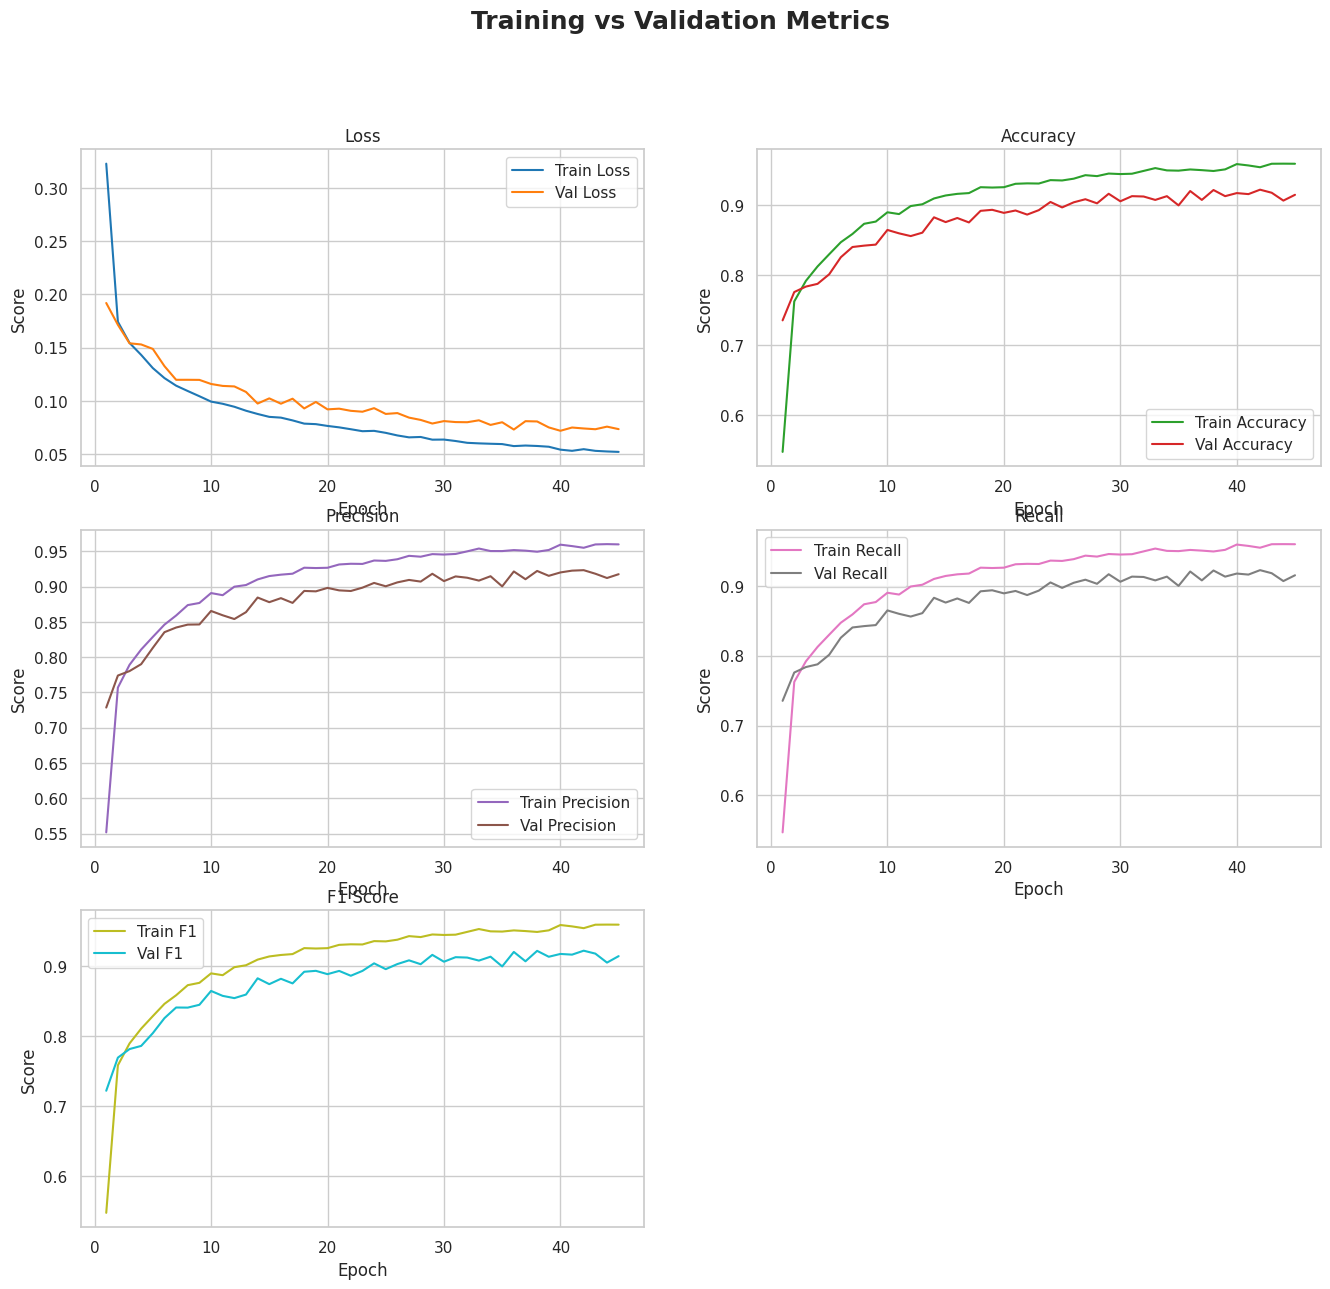

In [11]:
epochs_range = range(1, len(train_loss_list) + 1)
sns.set_style("whitegrid")

fig, axs = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle("Training vs Validation Metrics", fontsize=18, fontweight='bold')

axs[0, 0].plot(epochs_range, train_loss_list, label="Train Loss", color="#1f77b4")
axs[0, 0].plot(epochs_range, val_loss_list, label="Val Loss", color="#ff7f0e")
axs[0, 0].set_title("Loss"); axs[0, 0].legend()

axs[0, 1].plot(epochs_range, train_acc_list, label="Train Accuracy", color="#2ca02c")
axs[0, 1].plot(epochs_range, val_acc_list, label="Val Accuracy", color="#d62728")
axs[0, 1].set_title("Accuracy"); axs[0, 1].legend()

axs[1, 0].plot(epochs_range, train_precision_list, label="Train Precision", color="#9467bd")
axs[1, 0].plot(epochs_range, val_precision_list, label="Val Precision", color="#8c564b")
axs[1, 0].set_title("Precision"); axs[1, 0].legend()

axs[1, 1].plot(epochs_range, train_recall_list, label="Train Recall", color="#e377c2")
axs[1, 1].plot(epochs_range, val_recall_list, label="Val Recall", color="#7f7f7f")
axs[1, 1].set_title("Recall"); axs[1, 1].legend()

axs[2, 0].plot(epochs_range, train_f1_list, label="Train F1", color="#bcbd22")
axs[2, 0].plot(epochs_range, val_f1_list, label="Val F1", color="#17becf")
axs[2, 0].set_title("F1 Score"); axs[2, 0].legend()

axs[2, 1].axis('off')

for ax in axs.flat:
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")

plt.tight_layout

Classification Report:

                      precision    recall  f1-score   support

     Mild Impairment       0.96      0.80      0.87       179
 Moderate Impairment       1.00      1.00      1.00        12
       No Impairment       0.83      0.94      0.88       640
Very Mild Impairment       0.83      0.73      0.78       448

            accuracy                           0.85      1279
           macro avg       0.91      0.87      0.88      1279
        weighted avg       0.85      0.85      0.84      1279



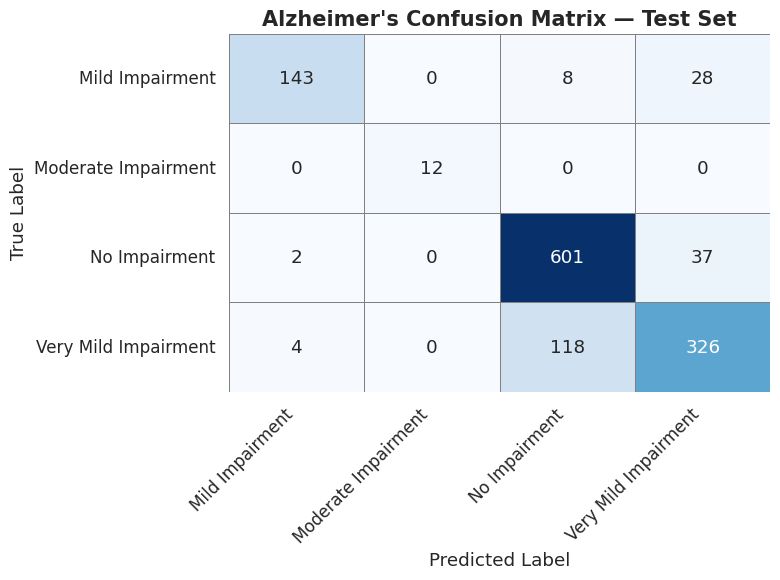


Overall Test Metrics:
Accuracy : 0.8460
Precision: 0.8494
Recall   : 0.8460
F1-Score : 0.8436


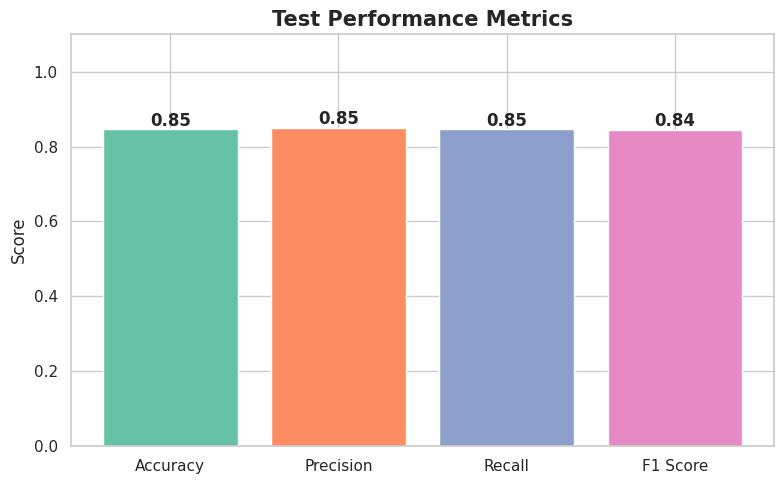

In [12]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# --- Classification report ---
report = classification_report(all_labels, all_preds, target_names=CLASS_NAMES)
print("Classification Report:\n")
print(report)

# --- Confusion matrix ---
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.set(font_scale=1.1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, linecolor='gray', cbar=False)
plt.title("Alzheimer's Confusion Matrix — Test Set", fontsize=15, fontweight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# --- Overall test metrics ---
test_accuracy = accuracy_score(all_labels, all_preds)
test_precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
test_recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
test_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print("\nOverall Test Metrics:")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-Score : {test_f1:.4f}")

# --- Bar chart of test metrics (matches thesis Fig 4.6) ---
metrics_dict = {"Accuracy": test_accuracy, "Precision": test_precision,
                 "Recall": test_recall, "F1 Score": test_f1}

plt.figure(figsize=(8, 5))
sns.set(style="whitegrid")
bars = plt.bar(list(metrics_dict.keys()), list(metrics_dict.values()),
                color=sns.color_palette("Set2", 4))
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01, f'{height:.2f}',
              ha='center', fontsize=12, fontweight='bold')
plt.ylim(0, 1.1)
plt.title("Test Performance Metrics", fontsize=15, fontweight='bold')
plt.ylabel("Score")
plt.tight_layout()
plt.show()

Total batches           : 160
Avg time per image (ms) : 1.1788
LAAI Score              : 0.8450


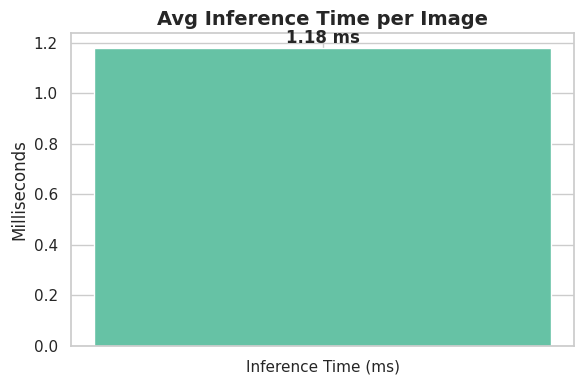


Latency-Accuracy Summary Table:


,Accuracy,Inference Time (ms),LAAI
0,0.845973,1.178777,0.844977


In [13]:
model.eval()
num_batches = 0
total_time = 0.0

# Warm-up run (avoids first-batch CUDA overhead skewing the timing)
with torch.no_grad():
    warmup_images, _ = next(iter(test_loader))
    _ = model(warmup_images.to(device))
    if device.type == "cuda":
        torch.cuda.synchronize()

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        if device.type == "cuda":
            torch.cuda.synchronize()
        start = time.time()
        _ = model(images)
        if device.type == "cuda":
            torch.cuda.synchronize()
        end = time.time()

        total_time += (end - start)
        num_batches += 1

avg_time_per_batch = total_time / num_batches
avg_time_per_image_ms = (avg_time_per_batch / BATCH_SIZE) * 1000

print(f"Total batches           : {num_batches}")
print(f"Avg time per image (ms) : {avg_time_per_image_ms:.4f}")

# LAAI = Accuracy / (1 + latency)  (thesis Eq. 3.2)
laai_score = test_accuracy / (1 + (avg_time_per_image_ms / 1000))  # latency in seconds, per thesis formula
print(f"LAAI Score              : {laai_score:.4f}")

# Bar chart (matches Fig 4.14)
plt.figure(figsize=(6, 4))
sns.set(style="whitegrid")
plt.bar(["Inference Time (ms)"], [avg_time_per_image_ms], color="#66c2a5")
plt.text(0, avg_time_per_image_ms + 0.02, f"{avg_time_per_image_ms:.2f} ms",
          ha='center', fontsize=12, fontweight='bold')
plt.title("Avg Inference Time per Image", fontsize=14, fontweight='bold')
plt.ylabel("Milliseconds")
plt.tight_layout()
plt.show()

print("\nLatency-Accuracy Summary Table:")
laai_table = pd.DataFrame({
    "Accuracy": [test_accuracy],
    "Inference Time (ms)": [avg_time_per_image_ms],
    "LAAI": [laai_score]
})
display(laai_table)

In [14]:
import os
os.makedirs("/content/artifacts", exist_ok=True)

torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": CLASS_NAMES,
    "img_size": IMG_SIZE,
    "test_accuracy": test_accuracy,
    "test_precision": test_precision,
    "test_recall": test_recall,
    "test_f1": test_f1,
}, "/content/artifacts/main_model.pth")

print("Saved main model checkpoint to /content/artifacts/main_model.pth")

Saved main model checkpoint to /content/artifacts/main_model.pth


In [17]:
NUM_EPOCHS_KFOLD = 15
N_SPLITS = 5
PATIENCE_KFOLD = 3

# --- Build one combined dataset (train + test folders) for K-Fold, matching thesis 3.4.2 ---
kfold_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

kfold_train_data = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=kfold_transforms)
kfold_test_data = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=kfold_transforms)

assert kfold_train_data.class_to_idx == kfold_test_data.class_to_idx, "Class mapping mismatch between train/test folders!"

full_dataset = ConcatDataset([kfold_train_data, kfold_test_data])
all_kfold_labels = [label for _, label in kfold_train_data.samples] + [label for _, label in kfold_test_data.samples]
all_kfold_indices = list(range(len(full_dataset)))

print(f"Total samples for K-Fold: {len(full_dataset)}")
from collections import Counter
print(f"Class distribution (combined): {Counter(all_kfold_labels)}")

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
fold_results = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'kappa': [], 'auroc': []}
last_fold_cm = None

for fold, (train_idx, val_idx) in enumerate(skf.split(all_kfold_indices, all_kfold_labels)):
    print(f"\n===================== FOLD {fold+1}/{N_SPLITS} =====================")

    train_subset = Subset(full_dataset, train_idx)
    val_subset = Subset(full_dataset, val_idx)

    fold_train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    fold_val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    fold_model = CNN_CapsuleNet(num_classes=NUM_CLASSES, img_size=IMG_SIZE).to(device)
    fold_criterion = CapsuleLoss(num_classes=NUM_CLASSES).to(device)
    fold_optimizer = optim.Adam(fold_model.parameters(), lr=LR)

    best_fold_val_loss = float('inf')
    best_fold_wts = copy.deepcopy(fold_model.state_dict())
    best_fold_epoch = 0
    fold_epochs_no_improve = 0

    for epoch in range(NUM_EPOCHS_KFOLD):
        fold_model.train()
        train_loss = 0.0
        for images, labels in fold_train_loader:
            images, labels = images.to(device), labels.to(device)
            fold_optimizer.zero_grad()
            outputs = fold_model(images)
            loss = fold_criterion(outputs, labels)
            loss.backward()
            fold_optimizer.step()
            train_loss += loss.item()
        train_loss /= len(fold_train_loader)

        fold_model.eval()
        val_loss = 0.0
        val_preds, val_labels_list = [], []
        val_softmax_list = []
        with torch.no_grad():
            for images, labels in fold_val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = fold_model(images)
                loss = fold_criterion(outputs, labels)
                val_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_labels_list.extend(labels.cpu().numpy())
                val_softmax_list.append(F.softmax(outputs, dim=1).cpu().numpy())
        val_loss /= len(fold_val_loader)

        val_acc = accuracy_score(val_labels_list, val_preds)
        val_f1 = f1_score(val_labels_list, val_preds, average='weighted', zero_division=0)
        val_kappa = cohen_kappa_score(val_labels_list, val_preds)
        val_softmax = np.concatenate(val_softmax_list, axis=0)
        try:
            val_auroc = roc_auc_score(np.array(val_labels_list), val_softmax, multi_class='ovr', average='weighted')
        except ValueError:
            val_auroc = float('nan')  # happens if a class is missing from this val fold

        print(f"  Epoch {epoch+1}/{NUM_EPOCHS_KFOLD} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, "
              f"Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}, Kappa: {val_kappa:.4f}, AUROC: {val_auroc:.4f}")

        if val_loss < best_fold_val_loss:
            best_fold_val_loss = val_loss
            best_fold_wts = copy.deepcopy(fold_model.state_dict())
            best_fold_epoch = epoch + 1
            fold_epochs_no_improve = 0
        else:
            fold_epochs_no_improve += 1
            if fold_epochs_no_improve >= PATIENCE_KFOLD:
                print(f"  Early stopping at epoch {epoch+1} for fold {fold+1}")
                break

    # Final evaluation with best weights for this fold
    fold_model.load_state_dict(best_fold_wts)
    fold_model.eval()
    final_preds, final_labels = [], []
    final_softmax_list = []
    with torch.no_grad():
        for images, labels in fold_val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = fold_model(images)
            preds = torch.argmax(outputs, dim=1)
            final_preds.extend(preds.cpu().numpy())
            final_labels.extend(labels.cpu().numpy())
            final_softmax_list.append(F.softmax(outputs, dim=1).cpu().numpy())

    final_acc = accuracy_score(final_labels, final_preds)
    final_precision = precision_score(final_labels, final_preds, average='weighted', zero_division=0)
    final_recall = recall_score(final_labels, final_preds, average='weighted', zero_division=0)
    final_f1 = f1_score(final_labels, final_preds, average='weighted', zero_division=0)
    final_kappa = cohen_kappa_score(final_labels, final_preds)
    final_softmax = np.concatenate(final_softmax_list, axis=0)
    final_auroc = roc_auc_score(np.array(final_labels), final_softmax, multi_class='ovr', average='weighted')
    final_cm = confusion_matrix(final_labels, final_preds)

    fold_results['accuracy'].append(final_acc)
    fold_results['precision'].append(final_precision)
    fold_results['recall'].append(final_recall)
    fold_results['f1'].append(final_f1)
    fold_results['kappa'].append(final_kappa)
    fold_results['auroc'].append(final_auroc)

    print(f"✅ Fold {fold+1} Final (best epoch {best_fold_epoch}): "
          f"Acc={final_acc:.4f}, F1={final_f1:.4f}, Kappa={final_kappa:.4f}, AUROC={final_auroc:.4f}")

    if fold == N_SPLITS - 1:
        last_fold_cm = final_cm
        last_fold_model_wts = best_fold_wts  # keep the last fold's best model for saving later

print("\n==================== K-FOLD SUMMARY ====================")
for metric, scores in fold_results.items():
    print(f"{metric.upper():<10}: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

Total samples for K-Fold: 11519
Class distribution (combined): Counter({2: 3200, 3: 3008, 0: 2739, 1: 2572})

===================== FOLD 1/5 =====================
  Epoch 1/15 - Train Loss: 0.1601, Val Loss: 0.0861, Val Acc: 0.9080, Val F1: 0.9089, Kappa: 0.8770, AUROC: 0.9878
  Epoch 2/15 - Train Loss: 0.0484, Val Loss: 0.0397, Val Acc: 0.9787, Val F1: 0.9787, Kappa: 0.9716, AUROC: 0.9984
  Epoch 3/15 - Train Loss: 0.0228, Val Loss: 0.0254, Val Acc: 0.9935, Val F1: 0.9935, Kappa: 0.9913, AUROC: 0.9998
  Epoch 4/15 - Train Loss: 0.0130, Val Loss: 0.0201, Val Acc: 0.9965, Val F1: 0.9965, Kappa: 0.9954, AUROC: 1.0000
  Epoch 5/15 - Train Loss: 0.0092, Val Loss: 0.0163, Val Acc: 0.9996, Val F1: 0.9996, Kappa: 0.9994, AUROC: 1.0000
  Epoch 6/15 - Train Loss: 0.0072, Val Loss: 0.0139, Val Acc: 0.9991, Val F1: 0.9991, Kappa: 0.9988, AUROC: 1.0000
  Epoch 7/15 - Train Loss: 0.0060, Val Loss: 0.0134, Val Acc: 0.9991, Val F1: 0.9991, Kappa: 0.9988, AUROC: 1.0000
  Epoch 8/15 - Train Loss: 0.004

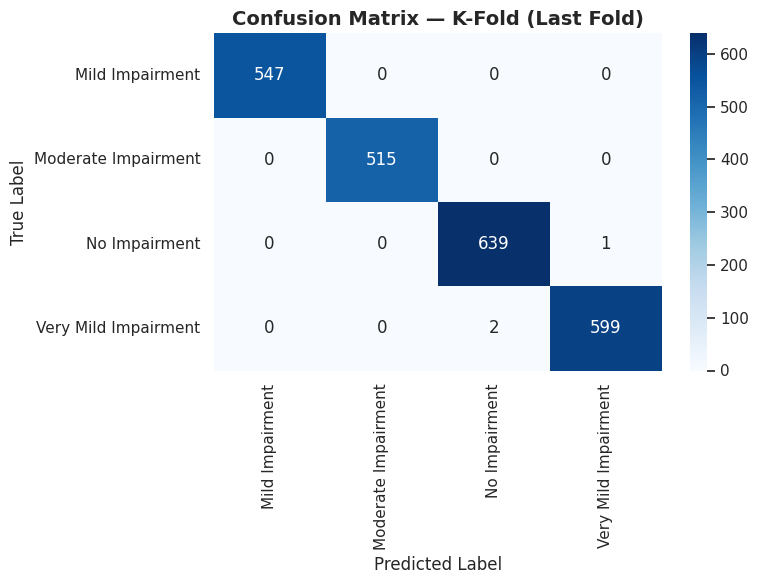

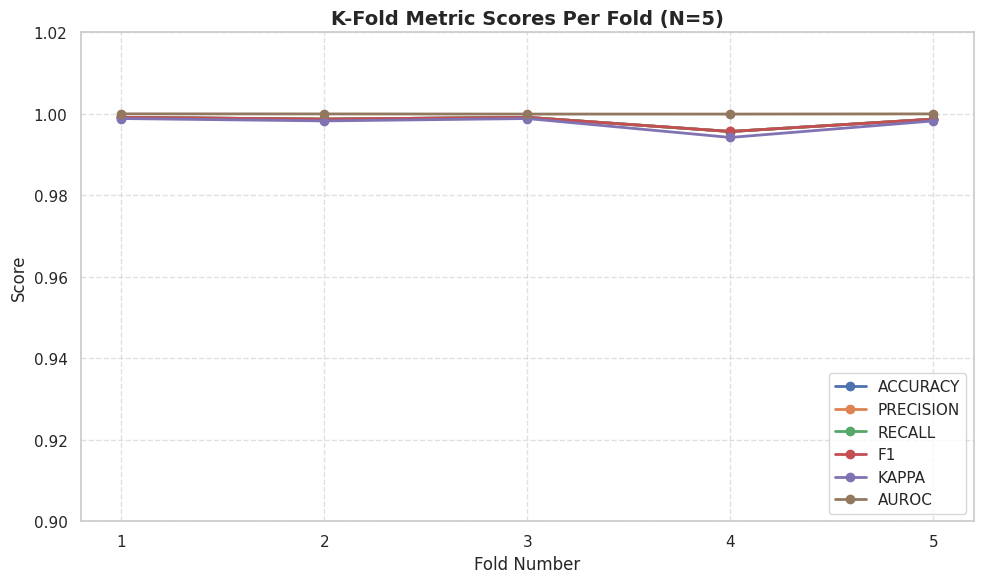

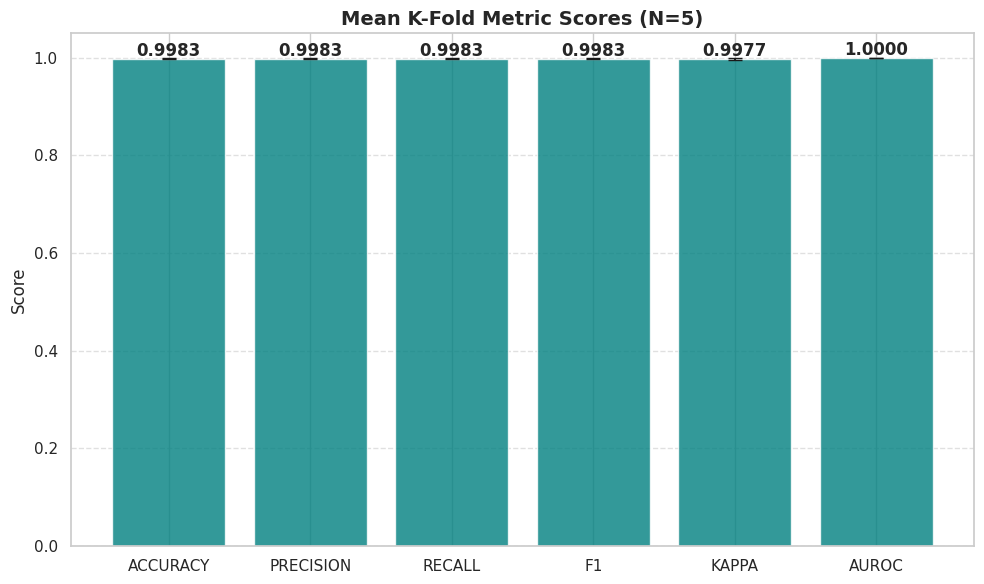


Final K-Fold Summary Table:


,ACCURACY,PRECISION,RECALL,F1,KAPPA,AUROC
0,0.9983 ± 0.0013,0.9983 ± 0.0013,0.9983 ± 0.0013,0.9983 ± 0.0013,0.9977 ± 0.0018,1.0000 ± 0.0000


In [18]:
# --- Confusion matrix of the last fold ---
plt.figure(figsize=(8, 6))
sns.heatmap(last_fold_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — K-Fold (Last Fold)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# --- Per-fold line chart ---
folds_range = list(range(1, N_SPLITS + 1))
plt.figure(figsize=(10, 6))
for metric, scores in fold_results.items():
    plt.plot(folds_range, scores, marker='o', label=metric.upper(), linewidth=2)
plt.title(f'K-Fold Metric Scores Per Fold (N={N_SPLITS})', fontsize=14, fontweight='bold')
plt.xlabel('Fold Number')
plt.ylabel('Score')
plt.xticks(folds_range)
plt.ylim(0.9, 1.02)
plt.legend(loc='lower right')
plt.grid(axis='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- Mean bar chart ---
metrics_names = [m.upper() for m in fold_results.keys()]
means = [np.mean(v) for v in fold_results.values()]
stds = [np.std(v) for v in fold_results.values()]

plt.figure(figsize=(10, 6))
plt.bar(metrics_names, means, yerr=stds, capsize=5, color='teal', alpha=0.8)
for i, (m, s) in enumerate(zip(means, stds)):
    plt.text(i, m + 0.005, f"{m:.4f}", ha='center', fontweight='bold')
plt.title(f'Mean K-Fold Metric Scores (N={N_SPLITS})', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\nFinal K-Fold Summary Table:")
kfold_summary_df = pd.DataFrame({
    metric.upper(): [f"{np.mean(v):.4f} ± {np.std(v):.4f}"] for metric, v in fold_results.items()
})
display(kfold_summary_df)

In [19]:
torch.save({
    "model_state_dict": last_fold_model_wts,
    "class_names": CLASS_NAMES,
    "img_size": IMG_SIZE,
    "kfold_summary": {k: {"mean": float(np.mean(v)), "std": float(np.std(v))} for k, v in fold_results.items()},
}, "/content/artifacts/kfold_model.pth")

print("Saved K-Fold representative model to /content/artifacts/kfold_model.pth")

Saved K-Fold representative model to /content/artifacts/kfold_model.pth


In [20]:
import zipfile

EXTERNAL_ZIP_PATH = "/content/test.zip"

EXTERNAL_EXTRACT_DIR = "/content/external_oasis_dataset"
os.makedirs(EXTERNAL_EXTRACT_DIR, exist_ok=True)

assert os.path.exists(EXTERNAL_ZIP_PATH), (
    f"Zip file not found at {EXTERNAL_ZIP_PATH}. "
    f"Files currently in /content: {os.listdir('/content')}"
)

with zipfile.ZipFile(EXTERNAL_ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTERNAL_EXTRACT_DIR)

print(f"Extracted to: {EXTERNAL_EXTRACT_DIR}\n")

# Discover the folder structure so we can see real class names before writing loading code
for dirpath, dirnames, filenames in os.walk(EXTERNAL_EXTRACT_DIR):
    depth = dirpath.replace(EXTERNAL_EXTRACT_DIR, '').count(os.sep)
    if depth <= 3:
        indent = "  " * depth
        n_files = len(filenames)
        print(f"{indent}{os.path.basename(dirpath) or '.'}/  ({n_files} files)" if n_files else f"{indent}{os.path.basename(dirpath) or '.'}/")

Extracted to: /content/external_oasis_dataset

external_oasis_dataset/
  test/  (640 files)


In [23]:
test_folder = "/content/external_oasis_dataset/test"
files = sorted(os.listdir(test_folder))

# Extract the prefix before "__" for every file
prefixes = [f.split("__")[0] for f in files]
prefix_counts = Counter(prefixes)
print("Unique label prefixes found and their counts:")
print(prefix_counts)
print(f"\nTotal files: {len(files)}  |  Sum of counts: {sum(prefix_counts.values())}")

Unique label prefixes found and their counts:
Counter({'ND': 320, 'VMD': 231, 'MD': 84, 'MoD': 5})

Total files: 640  |  Sum of counts: 640


In [24]:
from torch.utils.data import Dataset
from PIL import Image

# Mapping from Roboflow filename prefix -> our CLASS_NAMES index
PREFIX_TO_CLASS_IDX = {
    "MD": CLASS_NAMES.index("Mild Impairment"),
    "MoD": CLASS_NAMES.index("Moderate Impairment"),
    "ND": CLASS_NAMES.index("No Impairment"),
    "VMD": CLASS_NAMES.index("Very Mild Impairment"),
}
print("Prefix -> class index mapping:", PREFIX_TO_CLASS_IDX)


class ExternalTestDataset(Dataset):
    def __init__(self, folder, transform):
        self.folder = folder
        self.transform = transform
        self.samples = []
        for fname in sorted(os.listdir(folder)):
            prefix = fname.split("__")[0]
            if prefix not in PREFIX_TO_CLASS_IDX:
                continue  # skip anything unexpected instead of crashing
            label = PREFIX_TO_CLASS_IDX[prefix]
            self.samples.append((fname, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fname, label = self.samples[idx]
        img_path = os.path.join(self.folder, fname)
        image = Image.open(img_path).convert("L")  # grayscale
        image = self.transform(image)
        return image, label


external_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

external_dataset = ExternalTestDataset(test_folder, transform=external_transforms)
external_loader = DataLoader(external_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"External dataset loaded: {len(external_dataset)} samples")
print(f"Class distribution: {Counter([label for _, label in external_dataset.samples])}")

Prefix -> class index mapping: {'MD': 0, 'MoD': 1, 'ND': 2, 'VMD': 3}
External dataset loaded: 640 samples
Class distribution: Counter({2: 320, 3: 231, 0: 84, 1: 5})


Classification Report (External Validation):

                      precision    recall  f1-score   support

     Mild Impairment       0.86      0.87      0.86        84
 Moderate Impairment       1.00      1.00      1.00         5
       No Impairment       0.87      0.93      0.90       320
Very Mild Impairment       0.89      0.81      0.85       231

            accuracy                           0.88       640
           macro avg       0.91      0.90      0.90       640
        weighted avg       0.88      0.88      0.88       640



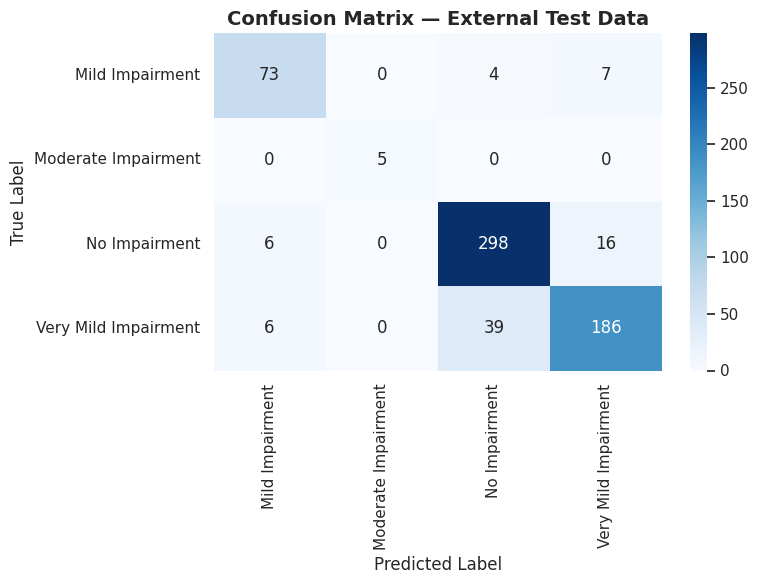


External Validation Accuracy : 0.8781
External Validation Precision: 0.8787
External Validation Recall   : 0.8781
External Validation F1       : 0.8772


In [25]:
# Use the main train/test-split model (Part 3/4). You could also try kfold model — see note below.
model.eval()
ext_preds, ext_labels = [], []

with torch.no_grad():
    for images, labels in external_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        ext_preds.extend(preds.cpu().numpy())
        ext_labels.extend(labels.cpu().numpy())

print("Classification Report (External Validation):\n")
print(classification_report(ext_labels, ext_preds, target_names=CLASS_NAMES, zero_division=0))

ext_cm = confusion_matrix(ext_labels, ext_preds, labels=list(range(NUM_CLASSES)))

plt.figure(figsize=(8, 6))
sns.heatmap(ext_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix — External Test Data", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

ext_accuracy = accuracy_score(ext_labels, ext_preds)
ext_precision = precision_score(ext_labels, ext_preds, average='weighted', zero_division=0)
ext_recall = recall_score(ext_labels, ext_preds, average='weighted', zero_division=0)
ext_f1 = f1_score(ext_labels, ext_preds, average='weighted', zero_division=0)

print(f"\nExternal Validation Accuracy : {ext_accuracy:.4f}")
print(f"External Validation Precision: {ext_precision:.4f}")
print(f"External Validation Recall   : {ext_recall:.4f}")
print(f"External Validation F1       : {ext_f1:.4f}")

In [26]:
external_validation_results = {
    "accuracy": ext_accuracy,
    "precision": ext_precision,
    "recall": ext_recall,
    "f1": ext_f1,
    "confusion_matrix": ext_cm.tolist(),
    "n_samples": len(external_dataset),
    "class_distribution": dict(Counter([label for _, label in external_dataset.samples]))
}
import json
with open("/content/artifacts/external_validation_results.json", "w") as f:
    json.dump(external_validation_results, f, indent=2)
print("Saved external validation results.")

Saved external validation results.


In [27]:
!pip install -q grad-cam lime

from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image

model.eval()
model.to(device)

# Last conv layer before the capsule layers (matches thesis 3.9.1 - Grad-CAM applied to last CNN layer)
target_layer = model.conv2
cam = GradCAMPlusPlus(model=model, target_layers=[target_layer])

viz_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

def load_and_prep_image(path):
    pil_img = Image.open(path).convert("L")
    tensor = viz_transform(pil_img).unsqueeze(0).to(device)
    display_img = tensor.squeeze().cpu().numpy() * 0.5 + 0.5  # unnormalize to [0,1]
    display_img_rgb = np.stack([display_img] * 3, axis=-1)
    return tensor, display_img_rgb

# Pick one sample image per class from the primary test folder
class_folders = {i: name for i, name in enumerate(CLASS_NAMES)}
sample_paths = {}
for idx, name in class_folders.items():
    folder = os.path.join(data_dir, "test", name)
    files_in_folder = os.listdir(folder)
    sample_paths[name] = os.path.join(folder, files_in_folder[0])

print("Sample images selected per class:")
for name, path in sample_paths.items():
    print(f"  {name}: {path}")

Sample images selected per class:
  Mild Impairment: /content/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test/Mild Impairment/19 (27).jpg
  Moderate Impairment: /content/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test/Moderate Impairment/17 (2).jpg
  No Impairment: /content/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test/No Impairment/25 (16).jpg
  Very Mild Impairment: /content/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test/Very Mild Impairment/9 (23).jpg


In [29]:
!pip install -q opencv-python-headless
import cv2

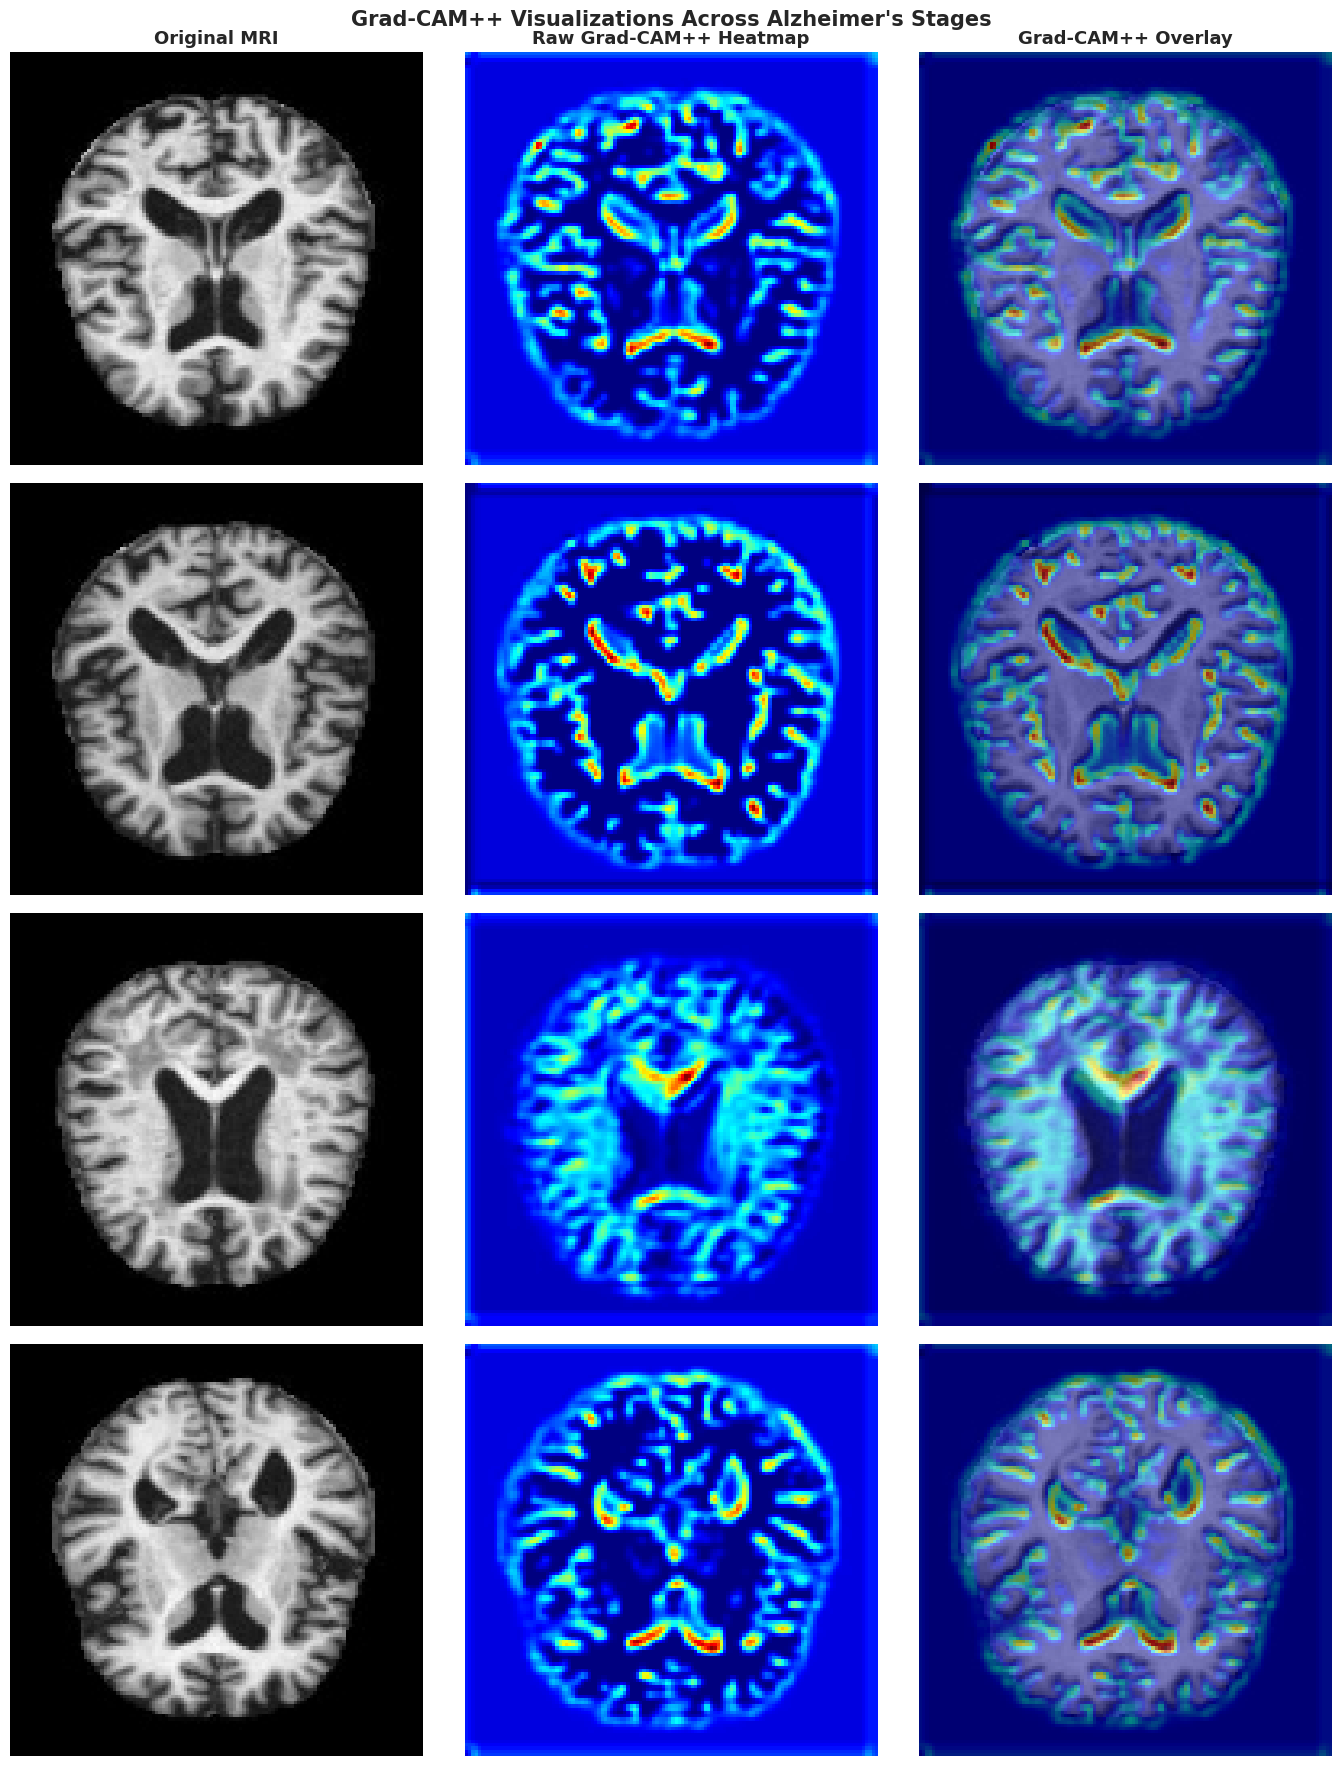

In [30]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(14, 18))
col_titles = ["Original MRI", "Raw Grad-CAM++ Heatmap", "Grad-CAM++ Overlay"]

for row, (class_name, path) in enumerate(sample_paths.items()):
    input_tensor, display_img = load_and_prep_image(path)

    grayscale_cam = cam(input_tensor=input_tensor)[0]
    visualization = show_cam_on_image(display_img, grayscale_cam, use_rgb=True)

    heatmap = cv2.applyColorMap(np.uint8(255 * grayscale_cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    axes[row, 0].imshow(display_img); axes[row, 0].axis('off')
    axes[row, 1].imshow(heatmap); axes[row, 1].axis('off')
    axes[row, 2].imshow(visualization); axes[row, 2].axis('off')

    axes[row, 0].set_ylabel(class_name, fontsize=11, fontweight='bold')

for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.suptitle("Grad-CAM++ Visualizations Across Alzheimer's Stages", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

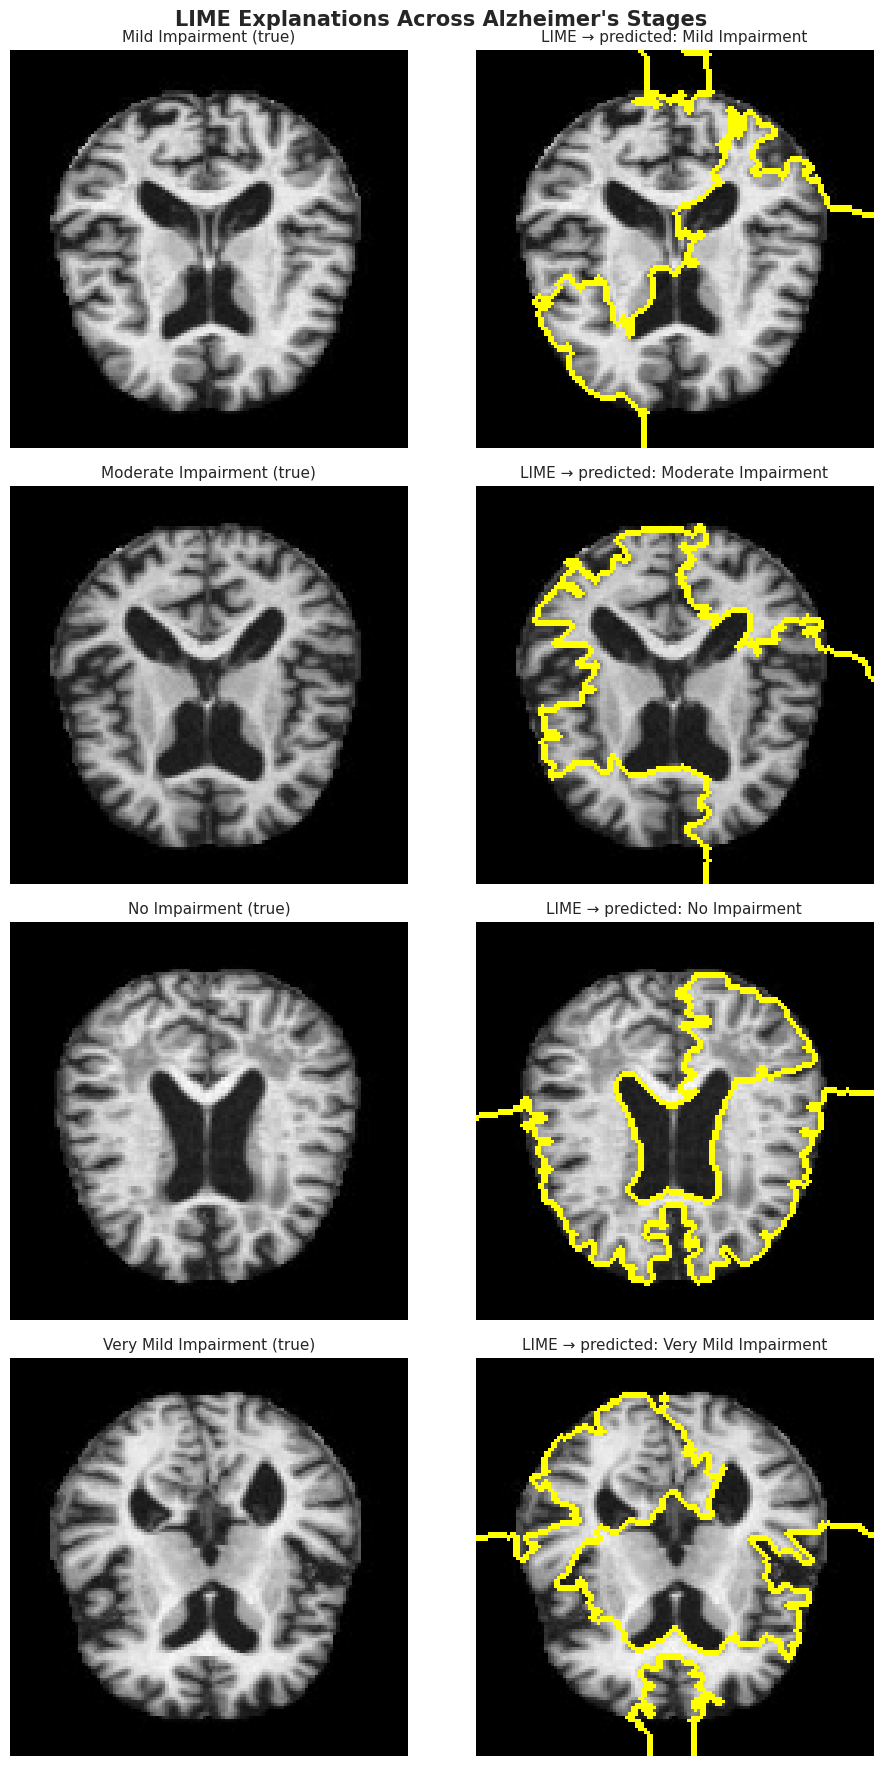

In [32]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

def batch_predict(images_np, model, device):
    """LIME calls this repeatedly with perturbed image batches (H, W, C) in [0, 255]."""
    model.eval()
    images_tensor = torch.tensor(images_np, dtype=torch.float32).permute(0, 3, 1, 2)
    images_tensor = images_tensor.mean(dim=1, keepdim=True)
    images_tensor = images_tensor / 255.0
    images_tensor = (images_tensor - 0.5) / 0.5
    images_tensor = images_tensor.to(device)

    with torch.no_grad():
        outputs = model(images_tensor)
        probs = F.softmax(outputs, dim=1)

    return probs.cpu().numpy()


explainer = lime_image.LimeImageExplainer()

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(10, 18))
col_titles = ["Original MRI", "LIME Explanation"]

for row, (class_name, path) in enumerate(sample_paths.items()):
    input_tensor, display_img = load_and_prep_image(path)

    lime_input_img = (display_img * 255).astype(np.uint8)

    explanation = explainer.explain_instance(
        lime_input_img,
        lambda x: batch_predict(x, model, device),
        top_labels=1,
        hide_color=0,
        num_samples=500
    )

    # Get the mask of the most influential superpixels (positive contribution only,
    # matching the thesis's "superpixel attribution" concept)
    _, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=5,
        hide_rest=False
    )

    predicted_class = CLASS_NAMES[explanation.top_labels[0]]

    # Draw ONLY yellow contour lines on top of the original grayscale image
    # (no green/red tinting) — matches thesis Fig 4.13 style
    lime_boundary_img = mark_boundaries(display_img, mask, color=(1, 1, 0), mode='thick')

    axes[row, 0].imshow(display_img, cmap='gray')
    axes[row, 0].axis('off')
    axes[row, 0].set_title(f"{class_name} (true)", fontsize=11)

    axes[row, 1].imshow(lime_boundary_img)
    axes[row, 1].axis('off')
    axes[row, 1].set_title(f"LIME → predicted: {predicted_class}", fontsize=11)

plt.suptitle("LIME Explanations Across Alzheimer's Stages", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [33]:
ablation_data = [
    ("Gao & Lima (2022)", "3D-DenseNet, 3D-CNN, ResNet+Attention", "ADNI, OASIS, AIBL", "Acc: 98.83%, F1: 99.61%"),
    ("Saleem et al. (2022)", "CNN, DNN, AE, RNN, GAN Hybrid", "ADNI, OASIS", "Acc: 53–99.95%"),
    ("Cheung et al. (2022)", "EfficientNet-B2 + Fusion + Grad-CAM", "12,949 Retinal Images", "Sens: 93.2%, AUROC: 0.93"),
    ("Zhou et al. (2025)", "3D-CNN + Swin Transformer + CBAM", "ADNI, OASIS", "ADNI: 92.92%, OASIS: 75.96%"),
    ("Shankar et al. (2025)", "GNN + QAOA", "ADNI", "Acc: 98.10%, AUC: 0.968"),
    ("Tawfeeq et al. (2025)", "ResNet50 + Transfer Learning", "Kaggle MRI", "Train: 95.84%, Test: 71.31%"),
    ("Nagarhalli et al. (2025)", "CNN + LSTM Fusion", "OASIS, ROSMAP", "Acc: 92.1%, AUC: 0.95"),
    ("Jraba et al. (2025)", "Enhanced YOLOv8", "ADNI MRI", "Precision: 96%, Inference <10ms"),
    ("Murugan et al. (2021) — DEMNET", "Lightweight CNN (4.5M params)", "Kaggle, ADNI", "Acc: 95.23%, AUC: 97%"),
    ("Farhan et al. (2025)", "CNN + LSTM (fMRI)", "ADNI fMRI", "Acc: 99.91% (binary)"),
    ("El-Assy et al. (2024)", "Dual Parallel CNN", "ADNI", "4-class Acc: 99.57%"),
    ("Antor et al. (2021)", "SVM/RF/DT (best: SVM)", "OASIS", "SVM Acc: 92.0%, F1: 91.9%"),
]

ablation_df = pd.DataFrame(ablation_data, columns=["Study", "Methodology", "Dataset(s)", "Key Performance"])

our_row = pd.DataFrame([{
    "Study": "NeuroXAI-Caps (This work, reproduced)",
    "Methodology": "CNN–CapsNet Hybrid + Grad-CAM++ + LIME",
    "Dataset(s)": "Kaggle MRI + External (Roboflow-derived) validation",
    "Key Performance": (
        f"Test Acc: {test_accuracy:.2%}, "
        f"K-Fold Acc: {np.mean(fold_results['accuracy']):.2%}, "
        f"K-Fold Kappa: {np.mean(fold_results['kappa']):.3f}, "
        f"External Acc: {ext_accuracy:.2%}, "
        f"Latency: {avg_time_per_image_ms:.2f} ms, LAAI: {laai_score:.3f}"
    )
}])

ablation_df = pd.concat([ablation_df, our_row], ignore_index=True)
display(ablation_df)

,Study,Methodology,Dataset(s),Key Performance
0,Gao & Lima (2022),"3D-DenseNet, 3D-CNN, ResNet+Attention","ADNI, OASIS, AIBL","Acc: 98.83%, F1: 99.61%"
1,Saleem et al. (2022),"CNN, DNN, AE, RNN, GAN Hybrid","ADNI, OASIS",Acc: 53–99.95%
2,Cheung et al. (2022),EfficientNet-B2 + Fusion + Grad-CAM,"12,949 Retinal Images","Sens: 93.2%, AUROC: 0.93"
3,Zhou et al. (2025),3D-CNN + Swin Transformer + CBAM,"ADNI, OASIS","ADNI: 92.92%, OASIS: 75.96%"
4,Shankar et al. (2025),GNN + QAOA,ADNI,"Acc: 98.10%, AUC: 0.968"
5,Tawfeeq et al. (2025),ResNet50 + Transfer Learning,Kaggle MRI,"Train: 95.84%, Test: 71.31%"
6,Nagarhalli et al. (2025),CNN + LSTM Fusion,"OASIS, ROSMAP","Acc: 92.1%, AUC: 0.95"
7,Jraba et al. (2025),Enhanced YOLOv8,ADNI MRI,"Precision: 96%, Inference <10ms"
8,Murugan et al. (2021) — DEMNET,Lightweight CNN (4.5M params),"Kaggle, ADNI","Acc: 95.23%, AUC: 97%"
9,Farhan et al. (2025),CNN + LSTM (fMRI),ADNI fMRI,Acc: 99.91% (binary)


In [34]:
print("="*70)
print("NEUROXAI-CAPS — FINAL REPRODUCED RESULTS SUMMARY")
print("="*70)

print(f"\n[Model]")
print(f"  Trainable parameters : {total_params:,}")

print(f"\n[Primary Train/Val/Test Split]")
print(f"  Test Accuracy  : {test_accuracy:.4f}")
print(f"  Test Precision : {test_precision:.4f}")
print(f"  Test Recall    : {test_recall:.4f}")
print(f"  Test F1-Score  : {test_f1:.4f}")

print(f"\n[5-Fold Stratified Cross-Validation]")
for metric, scores in fold_results.items():
    print(f"  {metric.upper():<10}: {np.mean(scores):.4f} ± {np.std(scores):.4f}")
print(f"  Note: near-perfect K-fold scores likely reflect train/test overlap in this")
print(f"  Kaggle dataset (combined train+test before splitting).")

print(f"\n[External Validation — Roboflow-derived test set, 640 samples]")
print(f"  Accuracy  : {ext_accuracy:.4f}")
print(f"  Precision : {ext_precision:.4f}")
print(f"  Recall    : {ext_recall:.4f}")
print(f"  F1-Score  : {ext_f1:.4f}")

print(f"\n[Efficiency]")
print(f"  Avg inference time : {avg_time_per_image_ms:.4f} ms/image")
print(f"  LAAI score         : {laai_score:.4f}")

print("\n" + "="*70)

NEUROXAI-CAPS — FINAL REPRODUCED RESULTS SUMMARY

[Model]
  Trainable parameters : 4,084,544

[Primary Train/Val/Test Split]
  Test Accuracy  : 0.8460
  Test Precision : 0.8494
  Test Recall    : 0.8460
  Test F1-Score  : 0.8436

[5-Fold Stratified Cross-Validation]
  ACCURACY  : 0.9983 ± 0.0013
  PRECISION : 0.9983 ± 0.0013
  RECALL    : 0.9983 ± 0.0013
  F1        : 0.9983 ± 0.0013
  KAPPA     : 0.9977 ± 0.0018
  AUROC     : 1.0000 ± 0.0000
  Note: near-perfect K-fold scores likely reflect train/test overlap in this
  Kaggle dataset (combined train+test before splitting).

[External Validation — Roboflow-derived test set, 640 samples]
  Accuracy  : 0.8781
  Precision : 0.8787
  Recall    : 0.8781
  F1-Score  : 0.8772

[Efficiency]
  Avg inference time : 1.1788 ms/image
  LAAI score         : 0.8450



In [35]:
final_summary = {
    "model_parameters": int(total_params),
    "main_split": {
        "test_accuracy": float(test_accuracy),
        "test_precision": float(test_precision),
        "test_recall": float(test_recall),
        "test_f1": float(test_f1),
    },
    "kfold": {k: {"mean": float(np.mean(v)), "std": float(np.std(v))} for k, v in fold_results.items()},
    "external_validation": external_validation_results,
    "efficiency": {
        "avg_inference_ms": float(avg_time_per_image_ms),
        "laai": float(laai_score),
    }
}

with open("/content/artifacts/final_summary.json", "w") as f:
    json.dump(final_summary, f, indent=2)

print("Saved final_summary.json")
print("\nAll artifacts in /content/artifacts:")
for f in os.listdir("/content/artifacts"):
    print(" ", f)

Saved final_summary.json

All artifacts in /content/artifacts:
  main_model.pth
  kfold_model.pth
  external_validation_results.json
  final_summary.json


In [38]:
import os
size_mb = os.path.getsize("/content/artifacts/main_model.pth") / (1024 * 1024)
print(f"main_model.pth size: {size_mb:.2f} MB")

main_model.pth size: 15.58 MB
